# 02 — Prompt Design: mit változtatunk és miért?

Ebben a notebookban a promptot **mérnöki komponensként** kezeljük. Nem az a cél, hogy nyolc véletlenszerű promptot kipróbáljunk, hanem hogy minden verziónál legyen egy világos hipotézis: milyen hibát próbálunk csökkenteni, milyen költséget vállalunk érte, és milyen metrikában várunk változást.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "02_notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")

Project root: <PROJECT_ROOT>


## 1. Kontrollált kísérlet

A final benchmarkban a fő független változó a **prompt strategy**.

Állandó marad:

- ugyanaz a modell;
- ugyanaz a holdout dataset;
- ugyanaz a mintasorrend;
- ugyanaz a parser;
- ugyanaz a metrikaszámítás;
- ugyanaz a pricing konfiguráció;
- ugyanaz a retry logika.

Így a különbségek sokkal jobban attribuálhatók a prompttervezéshez.

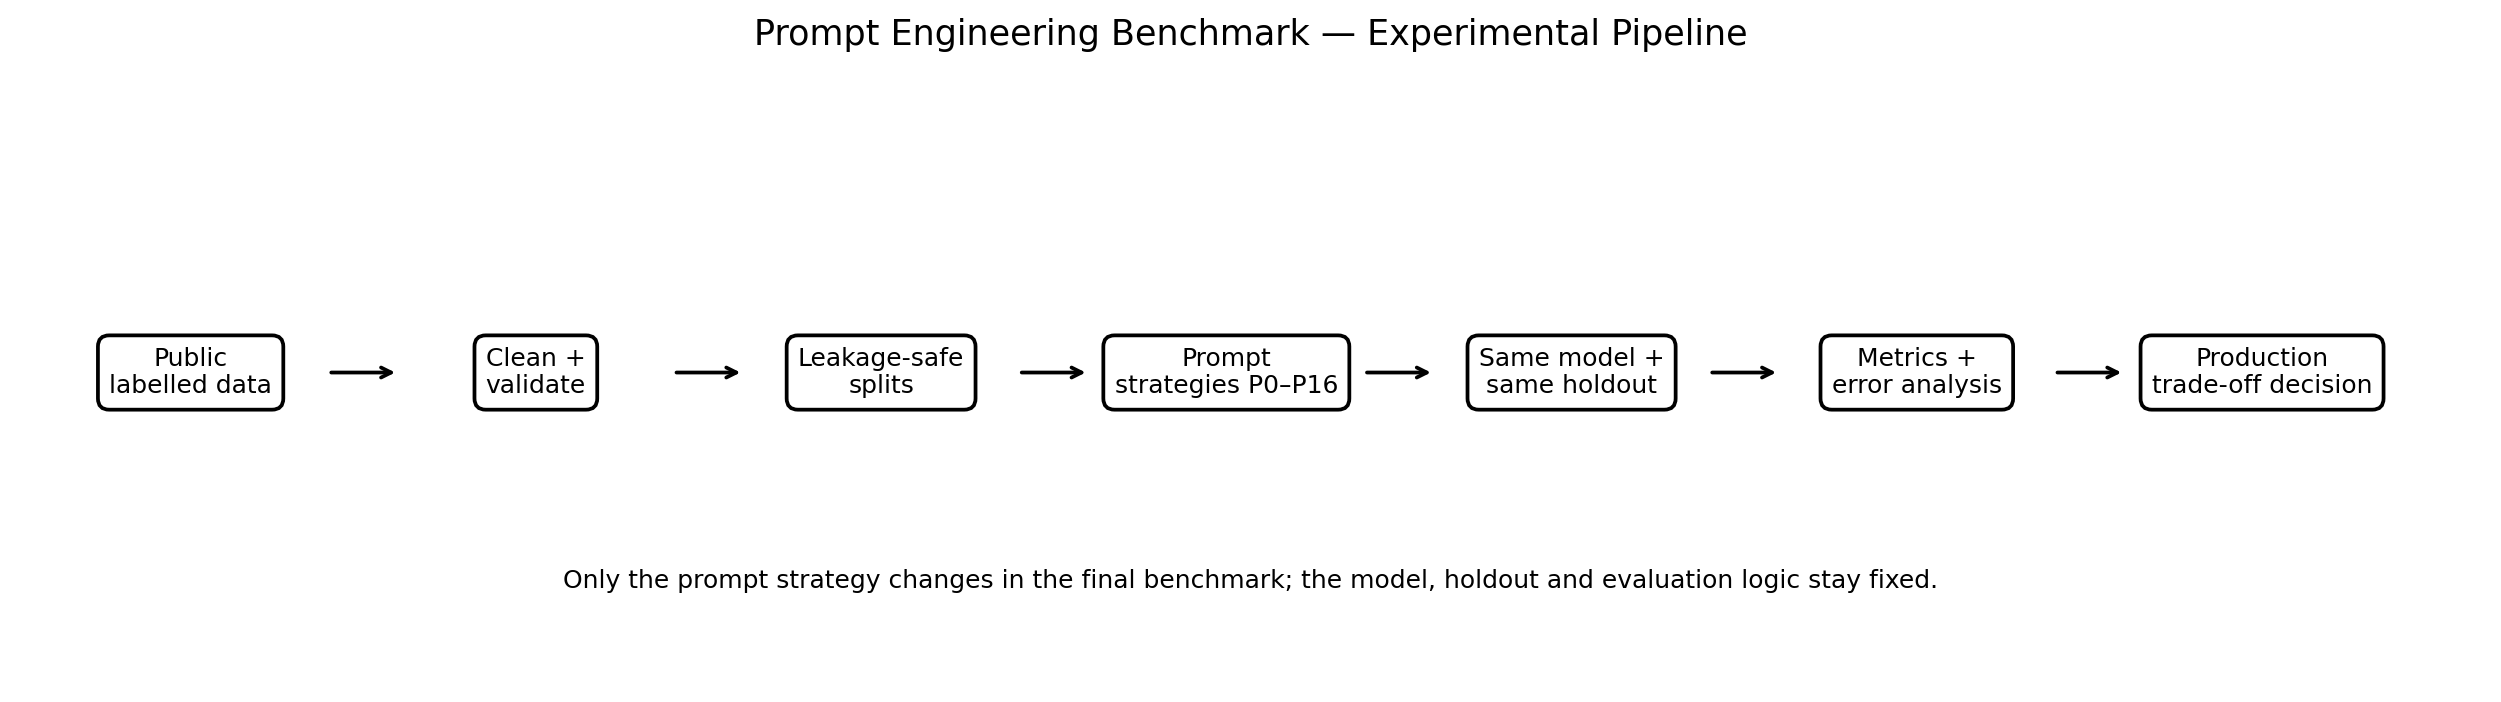

In [2]:
from IPython.display import Image, display

diagram = PROJECT_ROOT / "07_outputs/reports/figures/00_experiment_pipeline.png"
if diagram.exists():
    display(Image(filename=str(diagram)))
else:
    print("Run: python 05_scripts/08_generate_diagrams.py")

## 2. A P0–P7 stratégialétra

A promptok egymásra épülő mérnöki beavatkozásokat reprezentálnak. Ez azért fontos, mert egy recruiter így látja, hogy **nem csak promptokat gyártottunk, hanem komponenseket izoláltunk**.

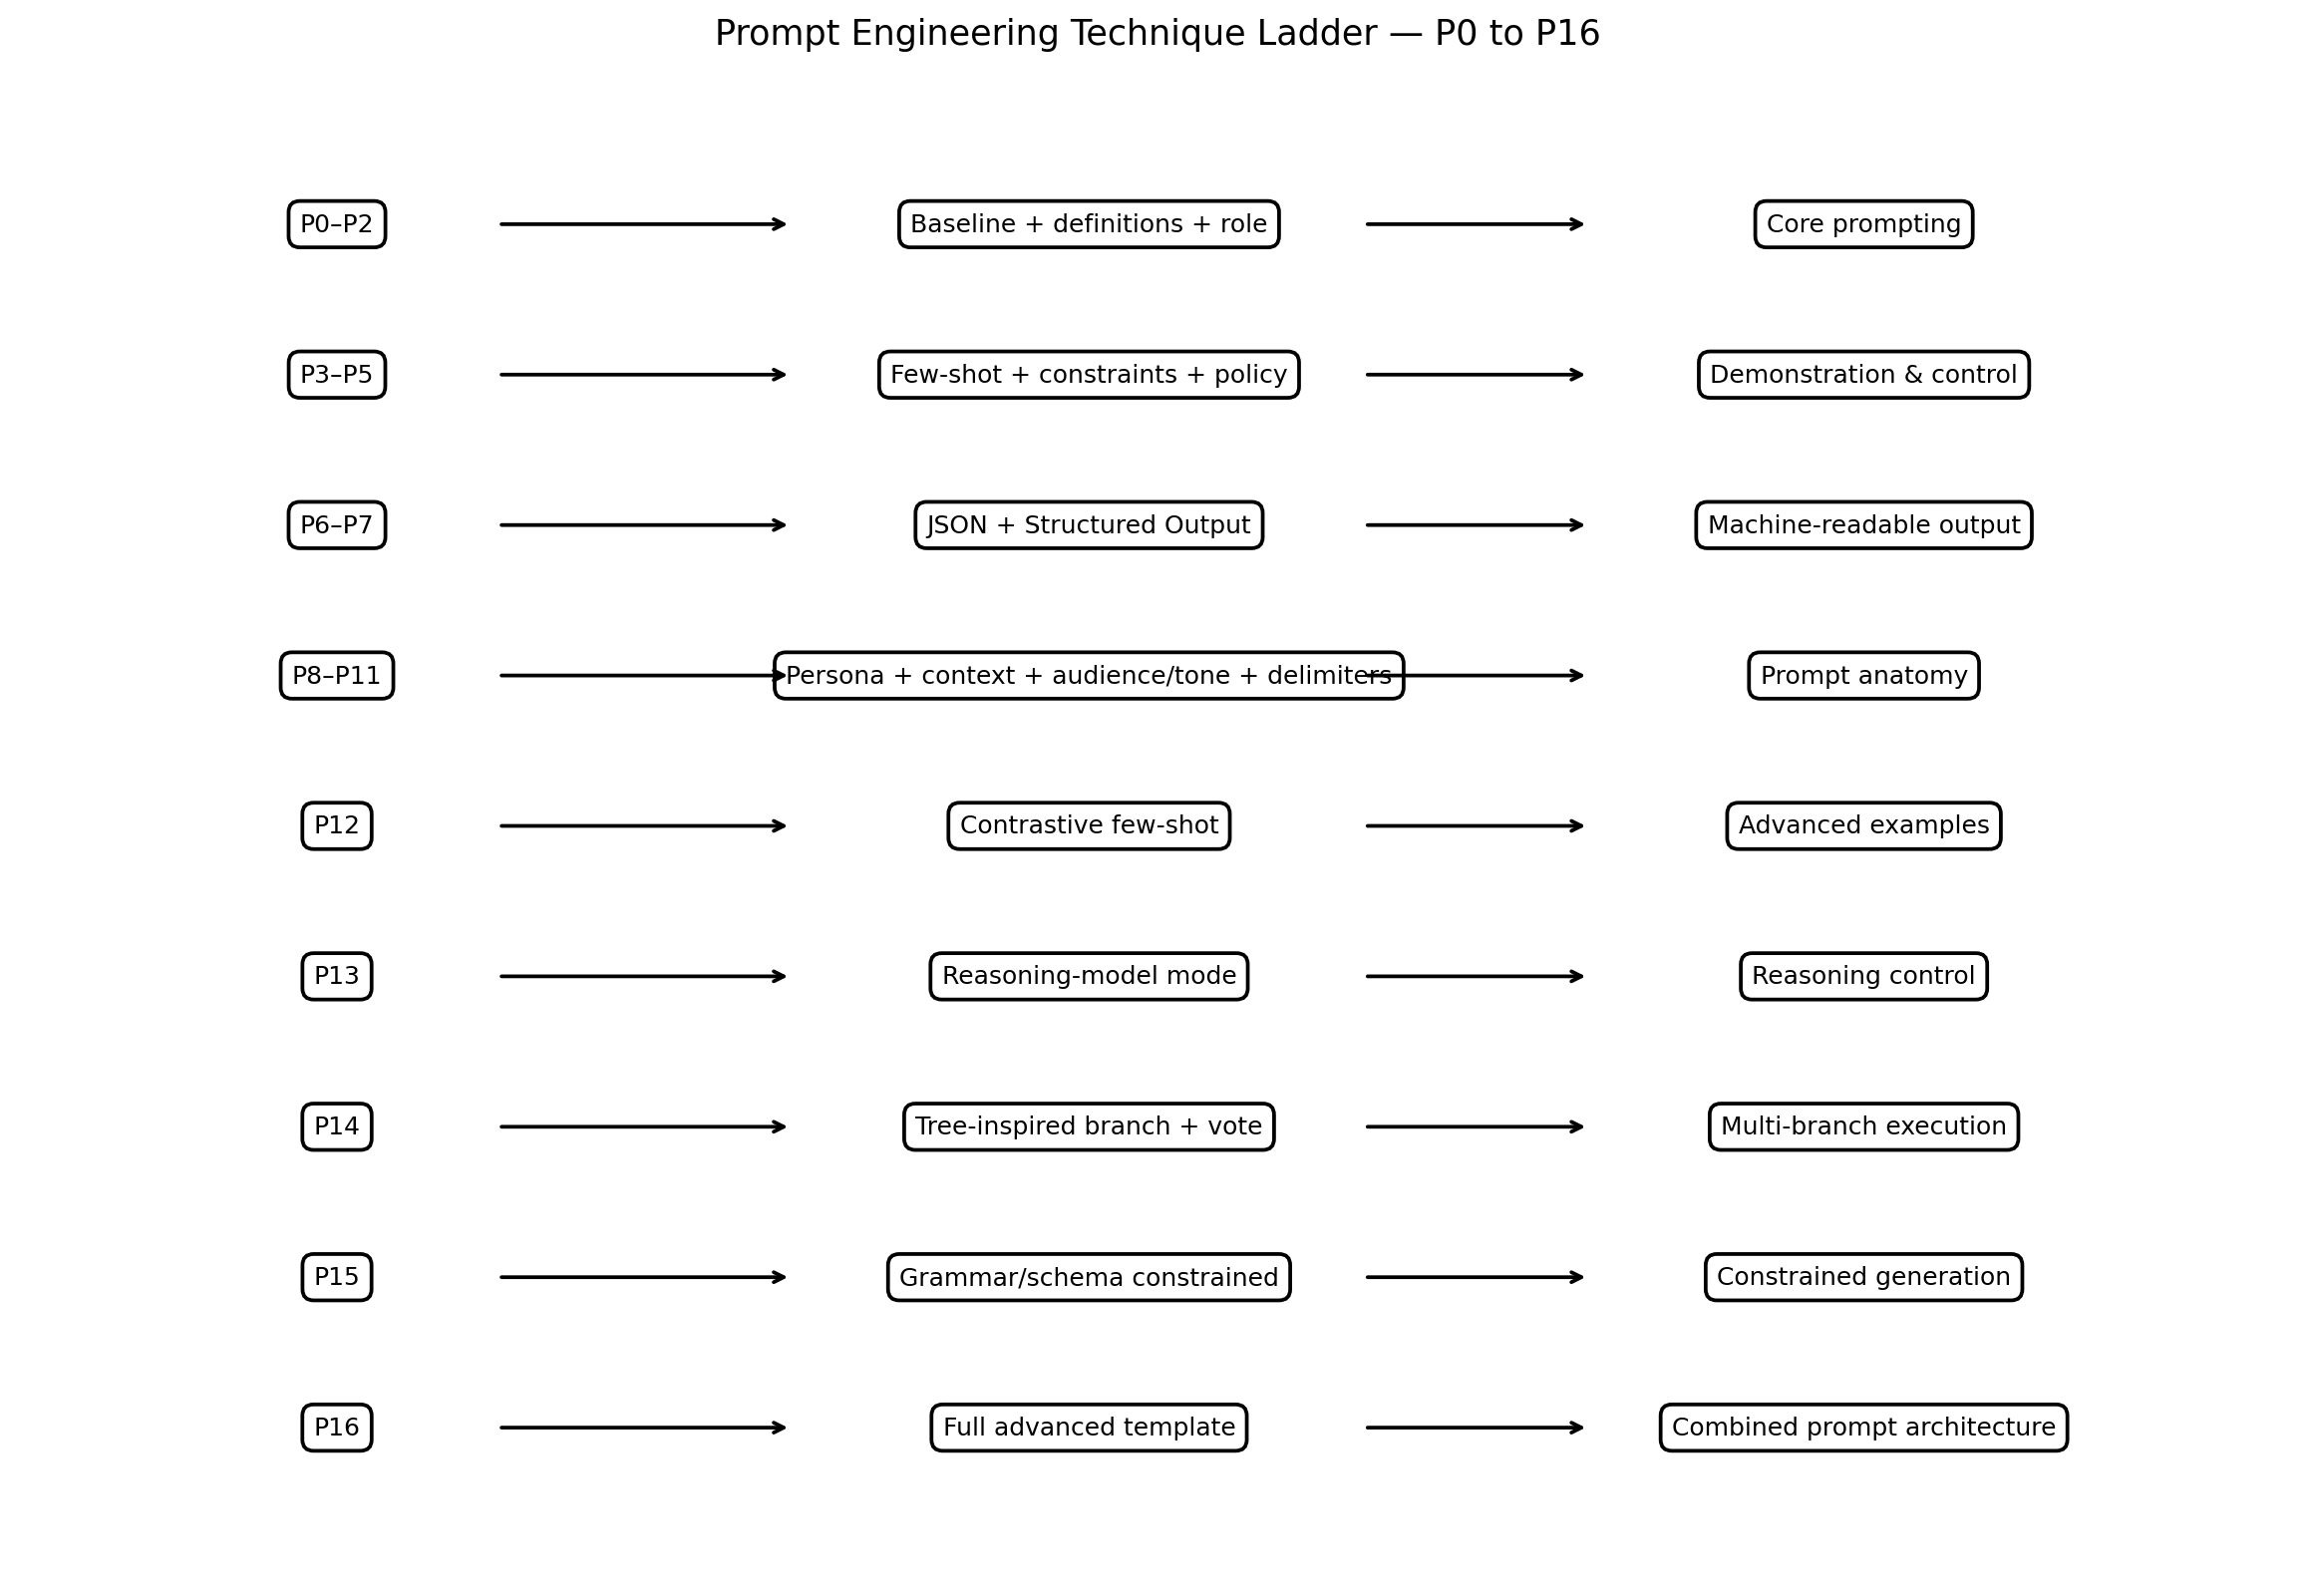

In [3]:
ladder = PROJECT_ROOT / "07_outputs/reports/figures/00c_prompt_strategy_ladder.png"
if ladder.exists():
    display(Image(filename=str(ladder)))

## 3. Előre rögzített hipotézisek

A jó benchmarkban a hipotézist **az eredmény előtt** megfogalmazzuk. Ellenkező esetben könnyű utólag minden eredményt „megmagyarázni”.

In [4]:
import pandas as pd

hypotheses = pd.DataFrame([
    ["P0", "Naive zero-shot", "Baseline", "Reference point for all later changes", "Low prompt cost, possibly ambiguous boundaries"],
    ["P1", "Label definitions", "Category semantics", "Reduce semantic confusion between labels", "Longer input prompt"],
    ["P2", "Role/system", "Task framing", "Improve instruction adherence", "May add little if base task is already clear"],
    ["P3", "Few-shot", "Demonstrations", "Show exact input→label mapping", "Highest token overhead growth"],
    ["P4", "Constraints", "Explicit rules", "Reduce verbose/invalid output and ambiguity", "Over-constraining can hurt edge cases"],
    ["P5", "Decision policy", "Routing logic", "Improve hard class boundaries", "Longer prompt; wrong policy can encode bias"],
    ["P6", "JSON prompt", "Machine-readable format", "Improve parseability", "Natural-language JSON instruction can still fail"],
    ["P7", "Structured Outputs", "Schema enforcement", "Maximize format reliability", "Provider/API-specific mechanism"],
], columns=["ID", "Strategy", "Changed component", "Expected benefit", "Main risk"])

hypotheses

,ID,Strategy,Changed component,Expected benefit,Main risk
0,P0,Naive zero-shot,Baseline,Reference point for all later changes,"Low prompt cost, possibly ambiguous boundaries"
1,P1,Label definitions,Category semantics,Reduce semantic confusion between labels,Longer input prompt
2,P2,Role/system,Task framing,Improve instruction adherence,May add little if base task is already clear
3,P3,Few-shot,Demonstrations,Show exact input→label mapping,Highest token overhead growth
4,P4,Constraints,Explicit rules,Reduce verbose/invalid output and ambiguity,Over-constraining can hurt edge cases
5,P5,Decision policy,Routing logic,Improve hard class boundaries,Longer prompt; wrong policy can encode bias
6,P6,JSON prompt,Machine-readable format,Improve parseability,Natural-language JSON instruction can still fail
7,P7,Structured Outputs,Schema enforcement,Maximize format reliability,Provider/API-specific mechanism


## 4. P0 — Naive Zero-Shot

**Miért kell gyenge baseline?**

Ha rögtön egy összetett prompttal kezdünk, nem tudjuk megmondani, mennyi értéket adtak hozzá az egyes komponensek. P0 ezért szándékosan minimális, de még korrekt task instructiont ad.

**Mit mérünk hozzá képest?** Minden későbbi Macro F1, validity, token és cost változást.

In [5]:
from prompt_benchmark.prompts import get_strategy

ticket = "I was charged twice this month."
payload = get_strategy("p0_zero_shot").build(ticket)
print(payload.input_text)

Classify this customer support message into one of: api, billing, cancellation, complaint, technical, upgrade.
Message: I was charged twice this month.
Return only the category.


## 5. P1 — Label Definitions

**Probléma:** az intentnevek rövidek, és határaik átfedhetnek. Például egy API-hívás technikai hibája lehet `api` vagy `technical`.

**Döntés:** definiáljuk az osztályok jelentését. Ez több input tokent használ, de elvileg csökkenti a szemantikai bizonytalanságot.

In [6]:
print(get_strategy("p1_definitions").build(ticket).input_text)

Classify this customer support message into one of: api, billing, cancellation, complaint, technical, upgrade.

Category definitions:
- api: API usage, authentication, endpoints, SDKs, integrations, API keys, or rate limits.
- billing: invoices, charges, payments, refunds, pricing, or payment failures.
- cancellation: explicit intent to cancel, terminate, stop, or not renew a subscription.
- complaint: general dissatisfaction or escalation without a more specific primary category.
- technical: bugs, crashes, errors, broken product behavior, login/application/system failures.
- upgrade: changing plan/tier, adding capacity/seats, upgrading or downgrading a subscription.

Message: I was charged twice this month.
Return only the category.


## 6. P2 — Role / System instruction

A role prompt itt nem „You are a genius” típusú díszítés. A rendszerüzenet világosan rögzíti, hogy az LLM **routing classifier**, tehát ne válaszolja meg a ticketet, hanem osztályozza.

**Hipotézis:** jobb instruction adherence; **kockázat:** lehet, hogy a hatás minimális, mert a task eleve egyszerű.

In [7]:
p = get_strategy("p2_role").build(ticket)
print("SYSTEM / INSTRUCTIONS:")
print(p.instructions)
print("\nUSER INPUT:")
print(p.input_text)

SYSTEM / INSTRUCTIONS:
You are a precise SaaS customer-support routing classifier.

USER INPUT:
Category definitions:
- api: API usage, authentication, endpoints, SDKs, integrations, API keys, or rate limits.
- billing: invoices, charges, payments, refunds, pricing, or payment failures.
- cancellation: explicit intent to cancel, terminate, stop, or not renew a subscription.
- complaint: general dissatisfaction or escalation without a more specific primary category.
- technical: bugs, crashes, errors, broken product behavior, login/application/system failures.
- upgrade: changing plan/tier, adding capacity/seats, upgrading or downgrading a subscription.

Message: I was charged twice this month.
Return exactly one of: api, billing, cancellation, complaint, technical, upgrade.


## 7. P3 — Few-Shot

Few-shot esetén konkrét példákat mutatunk a kívánt input→output mappingre.

**Miért 2 példa / class?** Elég ahhoz, hogy mind a hat intentet demonstráljuk, de nem növeli extrém módon a kontextust.

**Legfontosabb szabály:** a few-shot példa nem származhat sem a development, sem a final holdout készletből.

In [8]:
p = get_strategy("p3_few_shot").build(ticket)
print(p.input_text[:5000])

Category definitions:
- api: API usage, authentication, endpoints, SDKs, integrations, API keys, or rate limits.
- billing: invoices, charges, payments, refunds, pricing, or payment failures.
- cancellation: explicit intent to cancel, terminate, stop, or not renew a subscription.
- complaint: general dissatisfaction or escalation without a more specific primary category.
- technical: bugs, crashes, errors, broken product behavior, login/application/system failures.
- upgrade: changing plan/tier, adding capacity/seats, upgrading or downgrading a subscription.



Message: I was charged twice this month.
Return exactly one of: api, billing, cancellation, complaint, technical, upgrade.


## 8. P4 — Explicit Constraints

Itt a prompt azt is megmondja, mit **nem** tehet a modell:

- csak egy label;
- ne találjon ki új labelt;
- ne válaszolja meg a customer kérdését;
- primary intent alapján döntsön;
- `complaint` csak fallback legyen.

Ez tipikus production prompt engineering: a siker nem csak „jó tartalom”, hanem megbízható, parse-olható viselkedés.

In [9]:
print(get_strategy("p4_constraints").build(ticket).input_text[-1800:])

Category definitions:
- api: API usage, authentication, endpoints, SDKs, integrations, API keys, or rate limits.
- billing: invoices, charges, payments, refunds, pricing, or payment failures.
- cancellation: explicit intent to cancel, terminate, stop, or not renew a subscription.
- complaint: general dissatisfaction or escalation without a more specific primary category.
- technical: bugs, crashes, errors, broken product behavior, login/application/system failures.
- upgrade: changing plan/tier, adding capacity/seats, upgrading or downgrading a subscription.



Rules:
1. Select exactly one category.
2. Never invent a category.
3. Do not answer the customer's question.
4. If multiple topics appear, select the primary intent.
5. Prefer a specific category over complaint when a specific intent is clear.
6. Return no explanation.

Message: I was charged twice this month.
Allowed labels: api, billing, cancellation, complaint, technical, upgrade.


## 9. P5 — Decision Policy, Chain-of-Thought nélkül

A routing határokat explicit policy formájában adjuk meg. Nem kérünk step-by-step reasoningot és nem tárolunk belső gondolatmenetet; csak a döntési szabályrendszert tesszük egyértelművé.

**Miért?** Classificationnél a verbose reasoning drágább, lassabb és parsing szempontból felesleges. A cél a végső label minősége.

In [10]:
print(get_strategy("p5_decision_policy").build(ticket).input_text[-2200:])

Category definitions:
- api: API usage, authentication, endpoints, SDKs, integrations, API keys, or rate limits.
- billing: invoices, charges, payments, refunds, pricing, or payment failures.
- cancellation: explicit intent to cancel, terminate, stop, or not renew a subscription.
- complaint: general dissatisfaction or escalation without a more specific primary category.
- technical: bugs, crashes, errors, broken product behavior, login/application/system failures.
- upgrade: changing plan/tier, adding capacity/seats, upgrading or downgrading a subscription.



Rules:
1. Select exactly one category.
2. Never invent a category.
3. Do not answer the customer's question.
4. If multiple topics appear, select the primary intent.
5. Prefer a specific category over complaint when a specific intent is clear.
6. Return no explanation.

Decision policy to apply internally:
1. Explicit subscription termination/non-renewal -> cancellation.
2. Payment, invoice, charge, refund, pricing -> billing.
3

## 10. P6 — Prompt-only JSON

A gépi rendszernek gyakran strukturált output kell. P6-ban ezt **csak természetes nyelvi utasítással** kérjük.

Ez külön reliability benchmark: vajon a modell mindig szabályos JSON-t ad-e, ha csak megkérjük rá?

In [11]:
p = get_strategy("p6_json").build(ticket)
print("output_mode:", p.output_mode)
print("structured_output:", p.structured_output)
print(p.input_text[-900:])

output_mode: json
structured_output: False
ly one category.
2. Never invent a category.
3. Do not answer the customer's question.
4. If multiple topics appear, select the primary intent.
5. Prefer a specific category over complaint when a specific intent is clear.
6. Return no explanation.

Decision policy to apply internally:
1. Explicit subscription termination/non-renewal -> cancellation.
2. Payment, invoice, charge, refund, pricing -> billing.
3. API/SDK/key/endpoint/integration/rate-limit issue -> api.
4. Product malfunction, crash, login or software failure -> technical.
5. Plan/tier/capacity change -> upgrade.
6. Otherwise, general dissatisfaction/escalation -> complaint.
Return only the final classification; do not reveal hidden reasoning.

Message: I was charged twice this month.
Return valid JSON only, exactly like {"label": "billing"}. The label must be one of: api, billing, cancellation, complaint, technical, upgrade.


## 11. P7 — API-enforced Structured Outputs

P7 ugyanazt az üzleti döntést kéri, de a válaszformátumot JSON Schema korlátozza.

**Miért külön stratégia?** P6 és P7 összehasonlítása megmutatja a különbséget:

**prompt-only format control** vs **constrained generation**.

A P7 már nem pusztán prompt engineering; production LLM engineering elem is.

In [12]:
p = get_strategy("p7_structured_output").build(ticket)
print({"output_mode": p.output_mode, "structured_output": p.structured_output})

from prompt_benchmark.llm.schemas import SUPPORT_TICKET_JSON_SCHEMA
SUPPORT_TICKET_JSON_SCHEMA

{'output_mode': 'json', 'structured_output': True}


{'type': 'object',
 'properties': {'label': {'type': 'string',
   'enum': ['api',
    'billing',
    'cancellation',
    'complaint',
    'technical',
    'upgrade']}},
 'required': ['label'],
 'additionalProperties': False}

## 12. Prompt-komplexitás és token trade-off

A hosszabb prompt nem automatikusan jobb. A few-shot, constraints és decision policy extra kontextust adnak, de minden requestnél újra elküldjük őket.

Ezért már **a benchmark előtt** mérjük a promptok relatív méretét.

In [13]:
from prompt_benchmark.prompts import list_strategies

rows = []
placeholder = "[CUSTOMER SUPPORT TICKET]"
for name in list_strategies():
    payload = get_strategy(name).build(placeholder)
    text = f"{payload.instructions or ''}\n{payload.input_text}"
    rows.append({
        "strategy": name,
        "characters": len(text),
        "words": len(text.split()),
        "approx_tokens_chars_div_4": round(len(text) / 4, 1),
        "structured_output": payload.structured_output,
    })

prompt_size = pd.DataFrame(rows)
prompt_size

,strategy,characters,words,approx_tokens_chars_div_4,structured_output
0,p0_zero_shot,172,22,43.0,False
1,p1_definitions,739,93,184.8,False
2,p2_role,742,93,185.5,False
3,p3_few_shot,744,93,186.0,False
4,p4_constraints,1008,135,252.0,False
5,p5_decision_policy,1475,190,368.8,False
6,p6_json,1544,202,386.0,False
7,p7_structured_output,1400,182,350.0,True
8,p8_persona,862,108,215.5,False
9,p9_instruction_context,1257,172,314.2,False


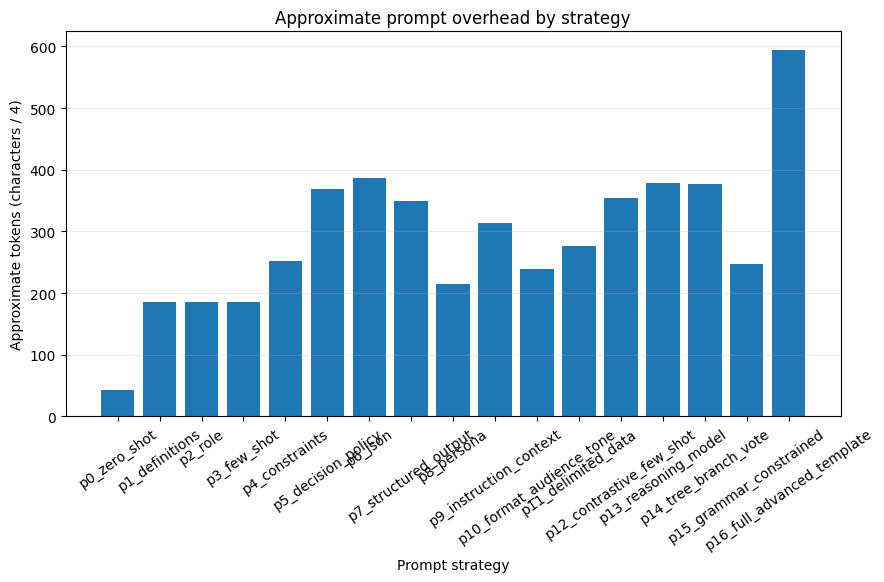

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(prompt_size["strategy"], prompt_size["approx_tokens_chars_div_4"])
ax.set_title("Approximate prompt overhead by strategy")
ax.set_ylabel("Approximate tokens (characters / 4)")
ax.set_xlabel("Prompt strategy")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.25)
plt.show()

### Fontos értelmezés

A `characters / 4` csak **durva becslés**, nem hivatalos tokenizer eredmény. A valódi benchmarkban az API által visszaadott input/output token usage az elsődleges mérés.

A becslés itt csak arra jó, hogy még futtatás előtt lássuk a relatív promptkomplexitást.

## 13. Mitől fair a P0–P7 összehasonlítás?

A promptok különböző hosszúságúak — ez szándékos, mert a prompt engineering ára is része a mérésnek. Ami viszont nem változhat: a modell, a holdout és az evaluation pipeline.

A következő notebookban ezeket ténylegesen lefuttatjuk, row-level logginggal és checkpointtal.